In [1]:
import numpy as np
from relativistic import relativistics, Deltap_p
from commonformulas import beam_rigidity, _2pi, get_units
from scipy.constants import c, e, electron_volt
import sympy as sy
def _a_(*args):
    return np.array(args)

from scipy.special import jv

import pandas as pd


energy_units, voltage_units, constants = get_units("eV", "V")

for key, value in energy_units.items():
    globals()[key] = value
for key, value in voltage_units.items():
    globals()[key] = value
for key, value in constants.items():
    globals()[key] = value

# h_bar = hbar_MeVs
# epsilon_0 = epsilon_0_e_MeVm



In [2]:
print("hbar, ", hbar_eVs, "eV * s")
print("epsilon_0_e^2/eVm", epsilon_0_e_eVm, "e^2 / eVm")



hbar,  6.582119569509067e-16 eV * s
epsilon_0_e^2/eVm 55263493.618020155 e^2 / eVm


In [2]:
def omega_critical(gamma, rho):
    return 3/2 * c / rho * gamma**3

def theta_critical(omega, omega_c, gamma):
    return 1/gamma * (omega_c/omega)**(1/3)

def theta_critical_Jackson(omega, omega_c, gamma):
    return np.sqrt((2*omega_c/omega + 1)**(2/3) - 1)/gamma


# def Cgamma_calc(E0):
#     return 1/(epsilon_0_e_eVm * E0**4)

def radiated_power(gamma, rho, q = 1):
    beta = np.sqrt(1-1/gamma**2)
    return q**2 * c * gamma**4/ (6*np.pi * epsilon_0_e_eVm * rho**2) * beta**2
    
def tau_y_calc(Enom, U0, T0, jy = 1):
    return 2/jy * Enom/U0 * T0

def tau_x_calc(Enom, U0, T0, jx):
    return 2/jx * Enom/U0 * T0

def tau_z_calc(Enom, U0, T0, jz):
    return 2/jz * Enom/U0 * T0


def epsilon_x_eq_calc(Cq, gamma, jx, I5, I2):
    return Cq * gamma**2 / jx * I5/I2

def beam_N_e(I_beam, T0):
    return I_beam * T0 / e



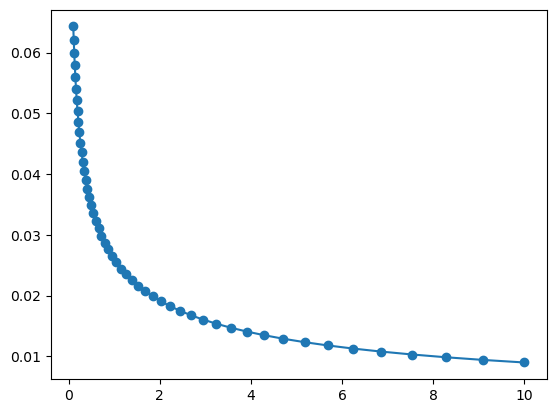

In [14]:
import matplotlib.pyplot as plt

omega_c = 1

gamma = 40

omega = np.logspace(np.log(omega_c)-1, np.log(omega_c)+1)

theta_c = theta_critical_Jackson(omega, omega_c, gamma)

xs, ys = [np.cos(theta_c), np.sin(theta_c)]

plt.plot(omega, theta_c, marker="o")

# Ex1


### .2

In [4]:
C0 = 26.7e3
E = 6.5e3*GeV
E0 = 938*MeV
B_dipoles = 7.7 #T
q=1

rels = relativistics(E0)

r = rels.given_E(E)

gamma = r["gamma"]
print("gamma", gamma)
p = r["p"]

brig = beam_rigidity()

rho = brig.rho(p, B_dipoles, q=q)
print("rho", rho)

omega_c = omega_critical(gamma, rho)


print("critical omega", omega_c)
E_c = omega_c * hbar_eVs

print("energy corresponding to the critical frequency", E_c)


P_r = radiated_power(gamma, rho)


l_dipoles = rho * _2pi

U_turn =  l_dipoles * P_r


print("radiated energy per turn", U_turn, "eV")


dipole_perc = l_dipoles/C0

print("circumference fractions for dipoles", dipole_perc )

gamma 6929.637562213974
rho 2815.8007743016465
critical omega 5.314245328451192e+16
energy corresponding to the critical frequency 34.97899817357073
radiated energy per turn 1480816553771.6843 eV
circumference fractions for dipoles 0.6626291405631838


### .3

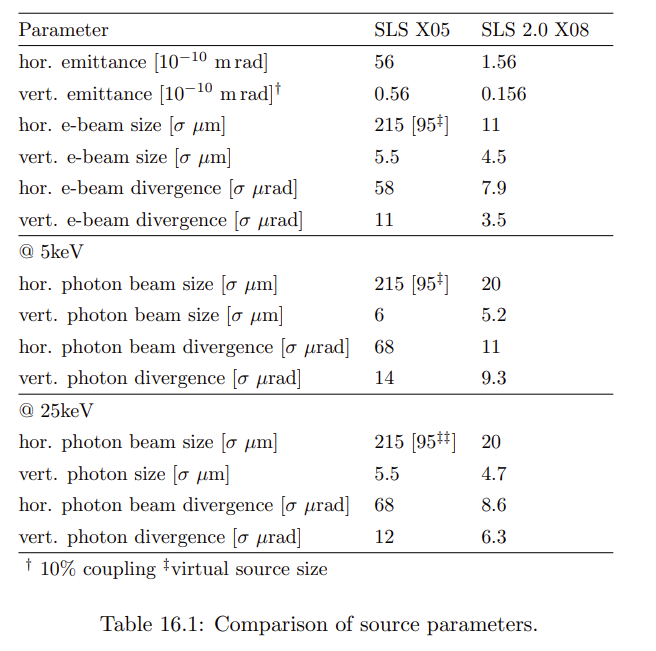

In [5]:


PETRA = {
"C0":2304,
"E":6*GeV,
"E0":511*keV,
}






SLS = {
    "C0":290.4,
    "E":2.7 *GeV,
    # "jx":1.71,
    # "jy":1,
    # "jz":1.29,
    # "I2":1.186,#m^-1
    # "I4":-0.842 #m^-1
    "epsilon_x":1.56e-10,
    "epsilon_y":0.156e-10
} 


df = pd.DataFrame([SLS, PETRA])

rels = relativistics(PETRA["E0"])
r = rels.given_E(df["E"])
df["gamma"] = r["gamma"]

df["I5/(I2*jx)"] = [df["epsilon_x"][0] / (df["C0"][0] * df["gamma"][0]**2), None]

df.loc[1, "I5/(I2*jx)"] =  df["I5/(I2*jx)"][0]# * df["C0"][1] * df["gamma"][1]**2

df.loc[1, "epsilon_x"] = df["I5/(I2*jx)"][1] * df["C0"][1] * df["gamma"][1]**2


print("a) horizontal emittance would be", df["epsilon_x"][1] * 1e9, "nm")

#ok, now we set the real emittance of PETRA



df.loc[1, "epsilon_x"] = 43e-12
df["By"] = [np.nan, 0.25]
df["p"] = r["p"]
df["beta"] = r["beta"]
df["rho"] = brig.rho(df["p"], df["By"])
df["P_rad"] = radiated_power(df["gamma"], df["rho"])

df["T0"] = df["C0"]/(df["beta"]*c)
df["U0"] = df["P_rad"] * df["T0"]
print("b) energy loss per turn = ",df["U0"][1]/eV, "eV/turn" )
df["beam_curr"] = [np.nan, 100e-3] #A
df["N_e"] = df["beam_curr"] * df["T0"] / e
df["total_rad_power"] = df["P_rad"] * (df["N_e"])

print("total radiated power for I_beam =  100 mA", df["total_rad_power"][1]*electron_volt, "W")
df["P_rad"]*electron_volt

a) horizontal emittance would be 6.112029449074146 nm
b) energy loss per turn =  6559690.528114013 eV/turn
total radiated power for I_beam =  100 mA 655969.0528114014 W


0             NaN
1    1.367515e-07
Name: P_rad, dtype: float64

In [6]:
df["gamma"]

0     5283.757343
1    11741.683046
Name: gamma, dtype: float64

In [7]:
2304 /(2*np.pi)

366.69298888372685

In [8]:
df["I5/(I2*jx)"][0] * df["C0"][1] * df["gamma"][1]**2

np.float64(6.112029449074146e-09)

# Ex 2

### .3

In [9]:
E = 6*GeV
E0 = 511*keV
rho = 25
f_rev = 1e6


rels = relativistics(E0)
r = rels.given_E(E)
P = radiated_power(r["gamma"], rho)

U0 = P * _2pi* rho / f_rev

print("a) U0", U0/GeV, "GeV")

tauy = tau_y_calc(E, U0, 1/f_rev)

print("b) tauy", tauy, "s")

t_half = np.log(2)/2 * tauy

print("c) t half emittance", t_half, "s")

a) U0 1.3748094589311506 GeV
b) tauy 8.72848227952216e-06 s
c) t half emittance 3.0250614413091148e-06 s


In [ ]:
# def residual_precision(exp_arg, nbits = 64):
#     return 1/2**(nbits - np.ceil(np.log2(np.abs(exp_arg))))

# residual_precision(-40)

np.float64(3.469446951953614e-18)

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

### .4

In [10]:
C0 = 290.4
E = 2.4 *GeV
jx = 1.71
jy = 1
jz = 1.29
I2 = 1.186 #m^-1
I4 = -0.842 #m^-1


rels = relativistics(E0)
r = rels.given_E(E)


T0 = C0/(c*r["beta"]) 

P = radiated_power(r["gamma"], rho)

U0 = P * _2pi* rho / f_rev


taux, tauy, tauz = [tau_x_calc(E, U0, T0, jx), tau_y_calc(E, U0, T0, jy), tau_z_calc(E, U0, T0, jz)]


print(f"taux =  {taux:.2e} tauy = {tauy:.2e} tauz = {tauz:.2e}, s" )





taux =  7.73e-05 tauy = 1.32e-04 tauz = 1.02e-04, s


### .6

In [35]:
C0 = 2.3e3 #m
E = 6*GeV
E0 = 511 * keV


rels = relativistics(E0)
r = rels.given_E(E)

gamma_old = r["gamma"]



epsilon_x_old = 1e-9
epsilon_x_new = 10e-12


epsilon_ratio = epsilon_x_new/epsilon_x_old
print("emmittance decrease", 1/epsilon_ratio, "times")

gamma_new = np.sqrt(epsilon_ratio) * gamma_old
r = rels.given_gamma(gamma_new)

print()


print(f"one may decrease the energy to {r["E"]/GeV} GeV, \nthis would decrease the gamma factor from {gamma_old} to {gamma_new} \nand so the reduce the equilibrium emittance by {1/epsilon_ratio} times")








emmittance decrease 100.00000000000001 times

one may decrease the energy to 0.6000000036476532 GeV, 
this would decrease the gamma factor from 11741.683045942333 to 1174.1683045942332 
and so the reduce the equilibrium emittance by 100.00000000000001 times


In [36]:
import PyPDF2 as pdf




read = pdf.PdfReader(r"ChapterI-10.pdf")

pages = read.pages[:25]

write = pdf.PdfWriter()
for p in pages: 
    write.add_page(p)

with open("reduced_chapter10.pdf" , "wb") as target:
    write.write(target)

### .7

reduced_chapter10.pdf

PDF

based on the content of the uploaded file and what you can find online, give me a picture about how the damping due to syncrtotron radiation affects the equations of motion in the  (y, py) phase space. You should be ideally able to come out with the equation of an harmonic oscillator, with a damping term related to the damping time for synchrotron radiation emission



### Short answer

**Radiation damping in the vertical plane converts the conservative betatron motion into a damped harmonic oscillator.** The single‑particle transverse equation becomes

$$\ddot y + \frac{2}{T_y}\dot y + \omega_y^2 y = 0,$$

so the **amplitude decays as $e^{-t/T_y}$** and the **vertical emittance decays as $e^{-2t/T_y}$**.

---

### Key idea and physical meaning

- **Undamped betatron motion:** without radiation the vertical motion is a simple harmonic oscillator with natural betatron frequency $\omega_y$:

  $$\ddot y + \omega_y^2 y = 0.$$

- **Radiation damping effect:** emission of photons removes forward momentum and, after RF re‑acceleration, produces a net reduction of transverse action. This acts like a viscous (velocity‑proportional) force in the transverse equation of motion, producing exponential damping of amplitudes.

---

### Short derivation

1. **Action and emittance:** the vertical action $J_y$ and the ensemble average (emittance) decay exponentially so that single‑particle amplitudes behave as $A(t)\propto e^{-t/T_y}$ and emittance as $E_y(t)\propto e^{-2t/T_y}$.

2. **Damped oscillator form:** an oscillator whose amplitude decays as $e^{-t/T_y}$ is governed by

   $$\ddot y + 2\alpha\dot y + \omega_y^2 y = 0,\qquad \alpha=\frac{1}{T_y},$$

   hence the **damped betatron equation**

   $$\boxed{\;\ddot y + \frac{2}{T_y}\dot y + \omega_y^2 y = 0\;}$$

   which yields amplitude $A(t)\propto e^{-t/T_y}$ and emittance $E_y\propto A^2\propto e^{-2t/T_y}$.

---

### Relation to the damping time $T_y$

- **Definition:** the vertical damping time can be written as

  $$T_y=\frac{2E_0}{U_0}\,T_0,$$

  where $E_0$ is the beam energy, $U_0$ the energy loss per turn and $T_0$ the revolution period.

- **Consequence:** larger energy loss per turn (stronger bending or stronger insertion devices) $\Rightarrow$ **shorter $T_y$** $\Rightarrow$ larger damping term $2/T_y$ $\Rightarrow$ faster suppression of betatron oscillations.

---

### Small‑damping limit and frequency shift

- For $2/T_y \ll \omega_y$ (typical electron rings), the motion is underdamped and the oscillation frequency is only slightly shifted:

  $$\omega' \approx \sqrt{\omega_y^2 - \left(\frac{1}{T_y}\right)^2}.$$

  The decay envelope remains $e^{-t/T_y}$.

---

### Practical notes and caveats

- **Quantum excitation:** photon emission is discrete; quantum excitation (photon recoil) competes with damping and sets a non‑zero equilibrium emittance. Damping alone would drive emittance to zero, but the balance with quantum excitation determines the steady state.

- **Modeling approaches:** include damping either as a continuous viscous term in the equations of motion or as a per‑turn multiplicative map in tracking codes (amplitude scaled by $e^{-T_0/T_y}$ per turn).

- **Typical regime:** electron storage rings are usually in the small‑damping, underdamped regime; protons experience negligible synchrotron damping except at extreme energies.

---

If you want, I can (a) show the same derivation in canonical $(y,p_y)$ variables with the per‑turn action change, (b) write the explicit per‑turn map $A_{n+1}=A_n e^{-T_0/T_y}$ and its relation to action variables, or (c) produce a short Python notebook that plots damped betatron motion for typical storage‑ring parameters. Which would you like next?